## Evaluation pipeline for the microlane experiment

In [1]:
# First consider all the variables
# The input image gets resized to a particular level
# Then create a pipeline to feed data into the model
# AFter this process is completed, then process the data
# Then after the processing is done find a way to take output from the model
# Then, convert the output to relevant format, and store it for future use
# Apply relevant computations

In [2]:
# Imports of the Core Packages
import json, sys, time
from pathlib import Path
from datetime import datetime

import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import yaml
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import random


In [3]:
# Import custom libraries located at different folder location + configs
from microlane.utils.metrics import *
from microlane.datasets.tusimple import TuSimple
from microlane.models.lanenet2.model import LaneNet2
from microlane.schema.output import ModelPrediction
from microlane.schema.sample import Sample
from microlane.utils.load_image import load_image_from_sample

In [4]:
# First Load the Configuation file
with open("configs/config.yaml", "r") as file:
    config = yaml.safe_load(file)

### Pre Processing Part

In [26]:
# First initialise the dataset
# Then load the dataset
dataset = TuSimple(
        folder_path=config['data']['datasets']['tusimple']['path'],
        annotation_file_path=config['data']['datasets']['tusimple']['annotation_file']
    )

data = dataset.load(number=10)

In [27]:
# Print some basic information of our data

print(f"Total items: {len(data)}\n")

random_image_index = random.randint(0, len(data)-1)

item = data[random_image_index]
print(f"Image Path   : {item.image_path}")
print(f"h_samples    : {item.h_samples}")
print(f"lanes        : {item.lanes}")

Total items: 10

Image Path   : /home/suyog/assets/datasets/TuSimple/TUSimple/test_set/clips/0530/1492627068602933406_0/20.jpg
h_samples    : [160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710]
lanes        : [[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 609, 577, 545, 513, 482, 450, 418, 386, 355, 323, 291, 259, 228, 196, 164, 132, 100, 69, 37, 5, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2], [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 654, 645, 636, 627, 618, 609, 601, 592, 583, 574, 565, 556, 547, 538, 529, 520, 511, 502, 493, 484, 475, 466, 457, 448, 439, 430, 421, 412, 403, 394, 386, 377, 368, 359, 350, 341, 332, 323, 314, 305, 296, 287, 278, 269, 260], [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 699

### Processing Part where we do the Inference

In [10]:
# So, basically now we will import the model
# model = LaneNet2() type and what we will do is, run 
# Run model.inference(formatted_dataset)

model = LaneNet2(
    
    container_folder=config['models']['lanenet2']['container_folder'],
    
    image_name=config['models']['lanenet2']['image_name']
)

Initializing container on port  8000
/home/suyog/desktop/projects/microlane/microlane/models/lanenet2/lanenet2
Image 'lanenet2_image:latest' already exists, skipping build.
Container already running: b81bbbb31103


In [28]:

loaded_image = load_image_from_sample(item)

In [29]:
response = model.predict(loaded_image)


# We are basically sending a loaded sample with this scchemas
# class Sample:
#     image_path: str
#     image: Optional[np.ndarray]  # None until actually loaded into memory
#     actual_lanes: List[LaneLine] 
    
#     brightness: float = 1.0
#     rotation: float = 0.0
#     zoom: float = 1.0
#     blur: float = 0.0

In [30]:
prediction = response.json()

ModelOutput = ModelPrediction (
    
    sample=Sample(
        
            image=prediction['sample']['image'],
            image_path=prediction['sample']['image_path'],
            h_samples=prediction['sample']['h_samples'],
            lanes=prediction['sample']['lanes'],
            blur=prediction['sample']['blur'],
            brightness=prediction['sample']['brightness'],
            zoom=prediction['sample']['zoom'],
            rotation=prediction['sample']['rotation']

        ),
    
    lanes=prediction['lanes'],
        
    inference_time=prediction['inference_time']
    
)

In [31]:

# Write Code to append this down to a JSON fileimport json
import os

# Build the output object in the required format
output_entry = {
    "lanes": ModelOutput.lanes,
    "h_samples": ModelOutput.sample.h_samples,
    "raw_file": ModelOutput.sample.image_path,
    "inference_time": ModelOutput.inference_time
}

# Path to your JSON file
json_file_path = "predictions.json"

# Load existing data or start fresh
if os.path.exists(json_file_path):
    with open(json_file_path, "r") as f:
        data = json.load(f)
    # Handle both list format and single object format
    if not isinstance(data, list):
        data = [data]
else:
    data = []

# Append new entry
data.append(output_entry)

# Write back to file
with open(json_file_path, "w") as f:
    json.dump(data, f, indent=2)

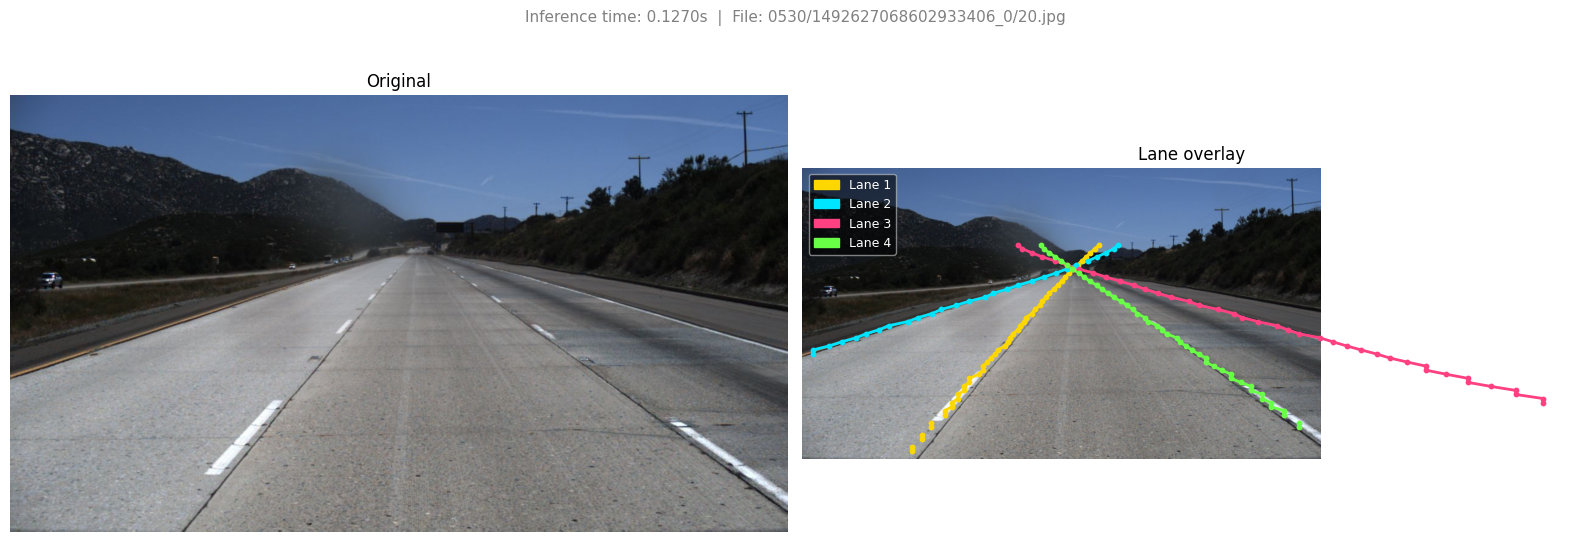

In [32]:

# Write Code to display the two Images Side By Side
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

COLORS = ['#FFD700', '#00E5FF', '#FF4081', '#69FF47', '#FF6D00', '#E040FB']

img = Image.open(ModelOutput.sample.image_path)
img_arr = np.array(img)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"Inference time: {ModelOutput.inference_time:.4f}s  |  "
    f"File: {'/'.join(ModelOutput.sample.image_path.split('/')[-3:])}",
    fontsize=11, color='gray'
)

axes[0].imshow(img_arr)
axes[0].set_title("Original", fontsize=12)
axes[0].axis("off")

axes[1].imshow(img_arr)
axes[1].set_title("Lane overlay", fontsize=12)
axes[1].axis("off")

legend_patches = []

for li, lane in enumerate(ModelOutput.lanes):
    color = COLORS[li % len(COLORS)]
    xs, ys = [], []

    for x, y in zip(lane, ModelOutput.sample.h_samples):
        if x == -2:
            if xs:
                axes[1].plot(xs, ys, color=color, linewidth=2)
                xs, ys = [], []
        else:
            xs.append(x)
            ys.append(y)

    if xs:
        axes[1].plot(xs, ys, color=color, linewidth=2)

    valid = [(x, y) for x, y in zip(lane, ModelOutput.sample.h_samples) if x != -2]
    if valid:
        vx, vy = zip(*valid)
        axes[1].scatter(vx, vy, color=color, s=10, zorder=5)

    legend_patches.append(mpatches.Patch(color=color, label=f"Lane {li+1}"))

axes[1].legend(handles=legend_patches, loc="upper left", fontsize=9,
               framealpha=0.6, facecolor='black', labelcolor='white')

plt.tight_layout()
plt.show()